In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, sem

/Users/linhdo/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 150)
decimal = 2
pd.set_option('display.float_format', lambda x: f'%.{decimal}f' % x)

# Average one-month simulation results

In [3]:
data_Q1 = pd.read_csv('./viz_data/gui_Q1.csv')
data_Q3 = pd.read_csv('./viz_data/gui_Q3.csv')
data_Q1_wind = pd.read_csv('./viz_data/gui_Q1_wind.csv')

In [4]:
def cleaning(data):
    data['self.day'] = (data['self.cycle'] / 287).round().astype(int)
    data['self.monthly_renew_charge / 1000'] = data['self.monthly_renew_charge / 1000']/22
    data['self.monthly_energy_consumption / 1000'] = data['self.monthly_energy_consumption / 1000']/22
    data.drop(columns=['int(self)', 'self.cycle'], inplace=True)
    data['self.monthly_profit'] = data['self.monthly_profit']/22/1000000

    
    test = data[['self.day', 'self.monthly_renew_charge / 1000', 'self.monthly_energy_consumption / 1000', 'self.self_sufficiency', 'self.self_consumption',  'self.monthly_revenue', 'self.monthly_cost', 'self.monthly_profit']]

    test = test.rename(columns={"self.day": "day", "self.monthly_renew_charge / 1000": "daily_renew_charge", "self.monthly_energy_consumption / 1000": "daily_total_consump", "self.self_sufficiency": "self_sufficiency", "self.self_consumption": "self_consumption", "self.monthly_revenue": "monthly_revenue", "self.monthly_cost": "monthly_cost", "self.monthly_profit": "monthly_profit"})
    
    return test

In [5]:
data_Q1_clean = cleaning(data_Q1)
data_Q3_clean = cleaning(data_Q3)
data_Q1_wind_clean = cleaning(data_Q1_wind)

In [6]:
def plot_energy(df1, df2):
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    titles = ["Quarter 1 (Jan-Mar): Daily Energy Trend", "Quarter 3 (July-Sep): Daily Energy Trend"]  
    legend_handles = []
    legend_labels = []

    for i, df in enumerate([df1, df2]):
        ax1 = axes[i]
        ax1.bar(df["day"], df["daily_total_consump"], color="gray", alpha=0.6, label="Total Consumption (kWh)")
        ax1.bar(df["day"], df["daily_renew_charge"], color="#648FFF", alpha=0.8, label="Renewable Energy (kWh)")
        ax1.set_xlabel("Day", fontsize=20)
        ax1.set_ylabel("Energy (kWh)", fontsize=20, color="black")
        ax1.tick_params(axis='y', labelcolor="black", labelsize=18)
        
        ax1.set_ylim(0, 1800)

        ax2 = ax1.twinx()
        ax2.plot(df["day"], df["self_sufficiency"], color="#FE6100", marker='o', label="Self-Sufficiency (%)")
        ax2.set_ylabel("Self-Sufficiency Ratio", fontsize=20, color="#FE6100")
        ax2.set_ylim(0, 1)
        ax2.tick_params(axis='y', labelcolor="#FE6100", labelsize=18)

        ax1.set_title(titles[i], fontsize=25, fontweight="bold")
        ax1.grid(axis="y", linestyle="--", alpha=0.5)
        ax1.set_xticks(df["day"])
        ax1.set_xticklabels([label if label in {1, 5, 10, 15, 20, 25, 30} else '' for label in df["day"]], fontsize=18)

        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        
        if not legend_handles:
            legend_handles.extend(handles1 + handles2)
            legend_labels.extend(labels1 + labels2)
            
    fig.legend(legend_handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=20, frameon=True)        
        
    plt.tight_layout()
    plt.show()

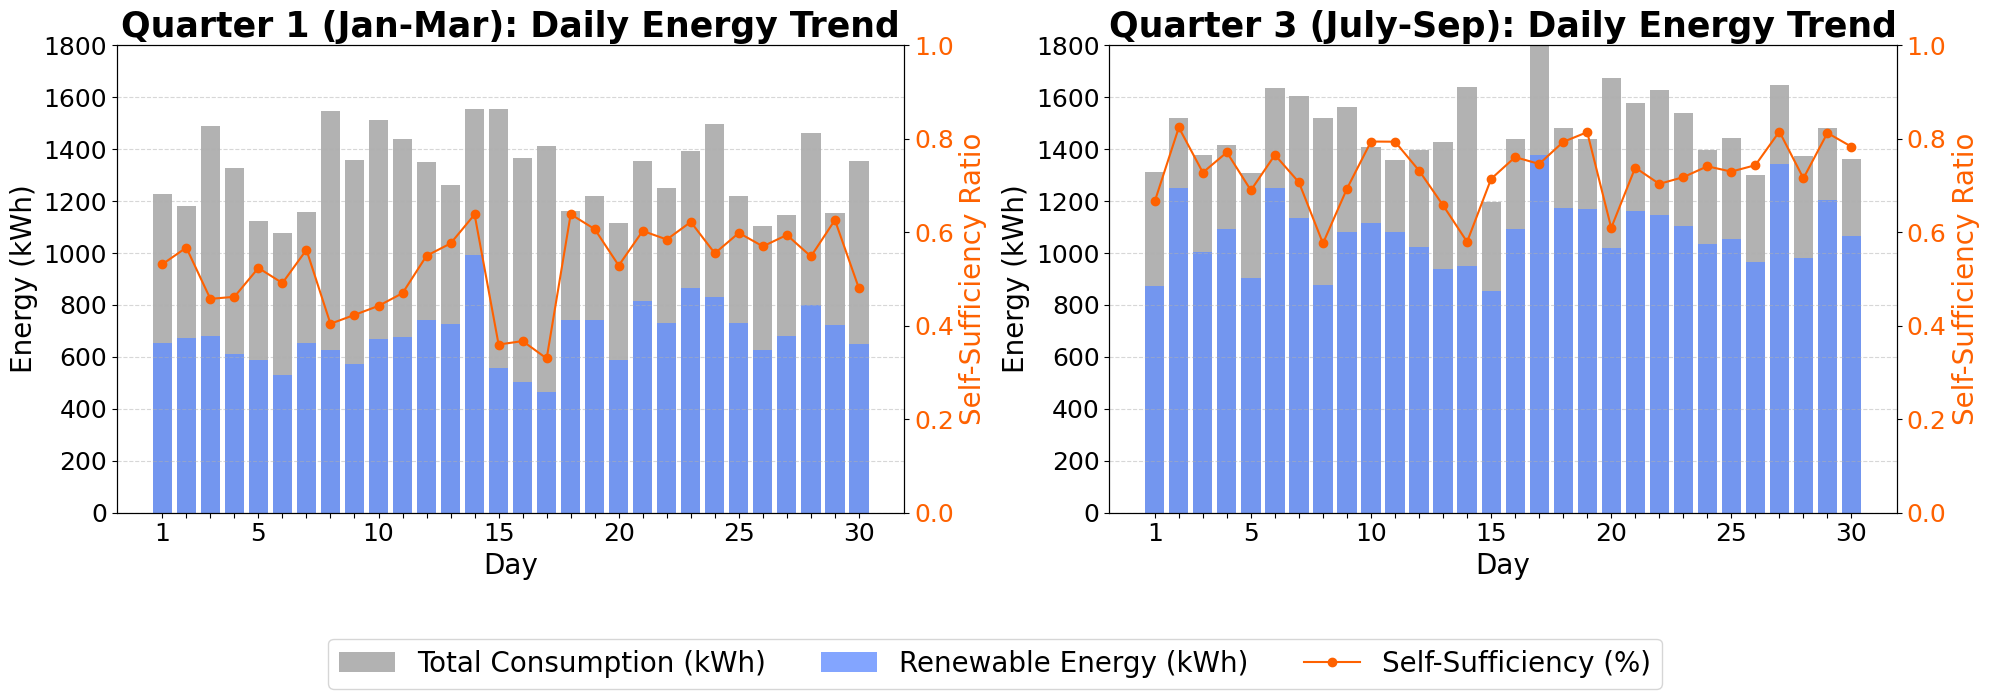

In [7]:
plot_energy(data_Q1_clean, data_Q3_clean)

In [8]:
def plot_self_sufficiency_comparison(df1, df2):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Compute Confidence Interval
    df1["self_sufficiency_mean"] = df1["self_sufficiency"].rolling(window=3, center=True).mean()
    df2["self_sufficiency_mean"] = df2["self_sufficiency"].rolling(window=3, center=True).mean()

    df1["self_sufficiency_se"] = df1["self_sufficiency"].rolling(window=3, center=True).apply(sem, raw=True)
    df2["self_sufficiency_se"] = df2["self_sufficiency"].rolling(window=3, center=True).apply(sem, raw=True)

    df1["ci_upper"] = df1["self_sufficiency_mean"] + 1.96 * df1["self_sufficiency_se"]
    df1["ci_lower"] = df1["self_sufficiency_mean"] - 1.96 * df1["self_sufficiency_se"]
    
    df2["ci_upper"] = df2["self_sufficiency_mean"] + 1.96 * df2["self_sufficiency_se"]
    df2["ci_lower"] = df2["self_sufficiency_mean"] - 1.96 * df2["self_sufficiency_se"]

    # Line Plot
    axes[0].plot(df1["day"], df1["self_sufficiency"], color="#648FFF", marker = 's', label="Without Wind Energy", markersize=8, linewidth=2.5)
    axes[0].plot(df2["day"], df2["self_sufficiency"], color="#FE6100", marker = 'o', label="With Wind Energy", markersize=8, linewidth=2.5)

    # Plot Confidence Interval
    axes[0].fill_between(df1["day"], df1["ci_lower"], df1["ci_upper"], color="#648FFF", alpha=0.2)
    axes[0].fill_between(df2["day"], df2["ci_lower"], df2["ci_upper"], color="#FE6100", alpha=0.2)

    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel("Day", fontsize=18)
    axes[0].set_ylabel("Self-Sufficiency Ratio", fontsize=18)
    axes[0].set_title("Self-Sufficiency Over Time", fontsize=20, fontweight="bold")

    axes[0].set_ylim(0, 1)
    axes[0].set_xticks(df1["day"])
    axes[0].set_xticklabels([label if label in {1, 5, 10, 15, 20, 25, 30} else '' for label in df1["day"]], fontsize=16)
    axes[0].set_yticks(np.linspace(0, 1, 6))
    axes[0].tick_params(axis='y', labelsize=16)
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)
    axes[0].legend(loc="upper right", fontsize=16)

    # Violin Plot
    df1["Scenario"] = "Without Wind Energy"
    df2["Scenario"] = "With Wind Energy"
    df = pd.concat([df1, df2])

    scenario_order = ["Without Wind Energy", "With Wind Energy"]
    summary_stats = df.groupby("Scenario")["self_sufficiency"].agg(["mean", "std", "min", "max"])
    summary_stats = summary_stats.loc[scenario_order]

    wilcoxon_test = wilcoxon(df1["self_sufficiency"], df2["self_sufficiency"])

    sns.violinplot(x="Scenario", y="self_sufficiency", data=df, 
                   order=scenario_order, 
                   palette={"Without Wind Energy": "#648FFF", "With Wind Energy": "#FE6100"}, 
                   inner="box", linewidth=1.5, ax=axes[1])
    
    axes[1].set_ylim(0, 1)

    for i, scenario in enumerate(scenario_order):
        mean_val = summary_stats.loc[scenario, "mean"]
        std_val = summary_stats.loc[scenario, "std"]
        min_val = summary_stats.loc[scenario, "min"]
        max_val = summary_stats.loc[scenario, "max"]
        
        axes[1].text(i, mean_val, f"Mean: {mean_val:.2f}\nStd: {std_val:.2f}", 
                     ha="center", va="center", fontsize=14, color="white", 
                     bbox=dict(facecolor='black', alpha=0.7, edgecolor='white'))

        axes[1].text(i, max_val + 0.05, f"Max: {max_val:.2f}", ha="center", fontsize=14, 
                     color="black", fontweight="bold", bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        axes[1].text(i, min_val - 0.05, f"Min: {min_val:.2f}", ha="center", fontsize=14, 
                     color="black", fontweight="bold", bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    axes[1].set_ylabel("Self-Sufficiency Ratio", fontsize=18)
    axes[1].set_xlabel("Scenario", fontsize=18)
    axes[1].set_title("Violin Plot of Self-Sufficiency", fontsize=20, fontweight="bold")
    axes[1].tick_params(axis='x', labelsize=16)
    axes[1].tick_params(axis='y', labelsize=16)
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    
    # Wilcoxon Test
    fig.text(0.5, -0.02, f"Wilcoxon Test: p-value = {wilcoxon_test.pvalue:.4f}", 
             fontsize=18, color="#FE6100", ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()


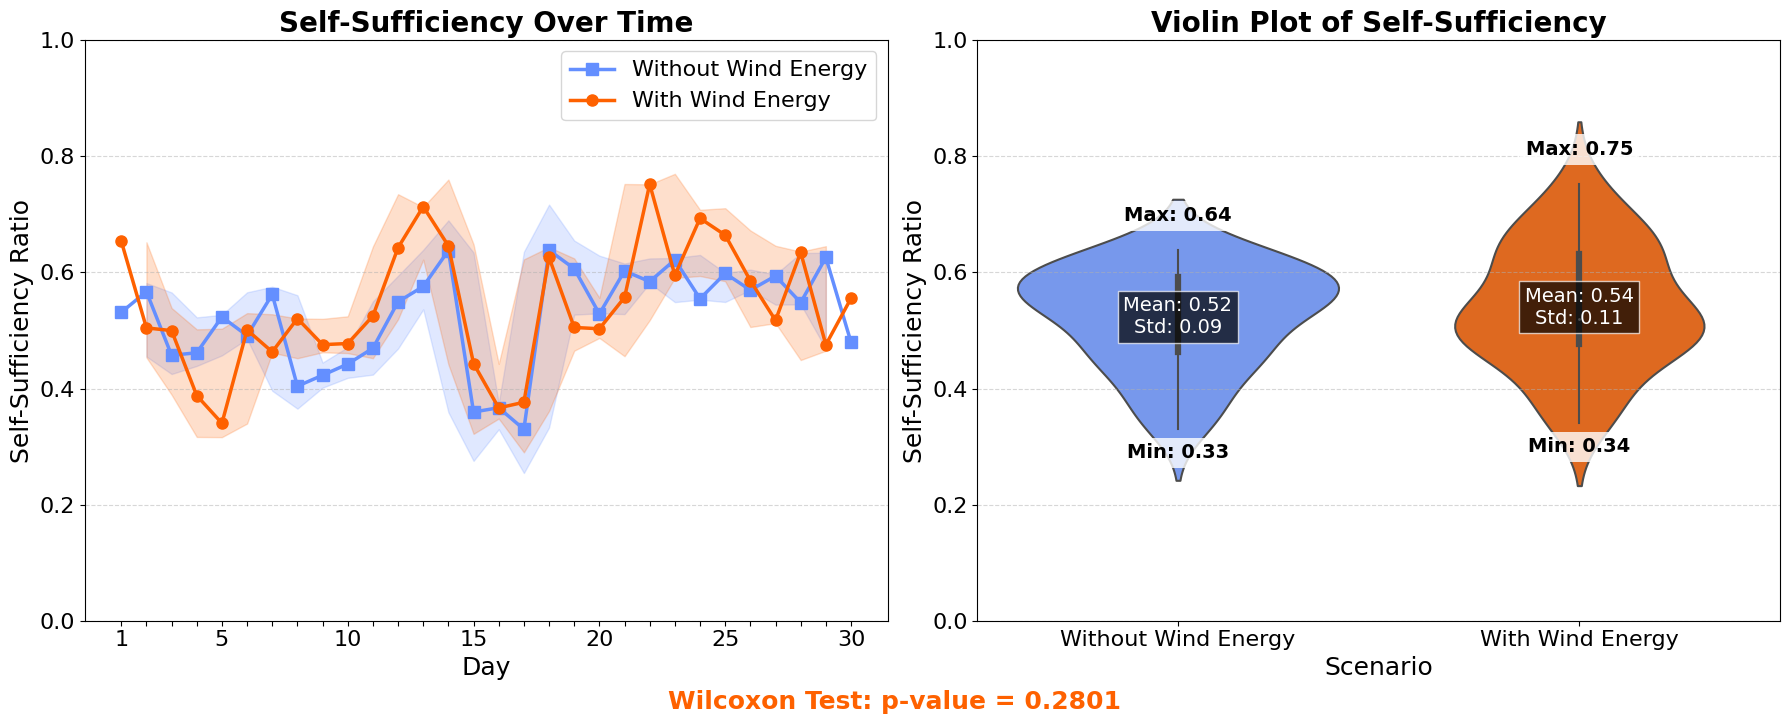

In [9]:
plot_self_sufficiency_comparison(data_Q1_clean, data_Q1_wind_clean)

# Analysis of Operational Policies

In [10]:
data_policy = pd.read_csv('./viz_data/policy_data.csv')

In [11]:
def compute_mean(data):
    mean_data = data.groupby(['self.nb_electrical', 'self.policy_ban_gasoline', 'self.policy_idle_fee', 'self.policy_relocation', 'self.policy_notification']).mean(numeric_only=True).reset_index()
    return mean_data

In [12]:
data_policy = compute_mean(data_policy)
data_policy.drop(columns=['int(self)'], inplace=True)

In [13]:
data_policy_test = data_policy[['self.nb_electrical', 'self.policy_ban_gasoline', 'self.policy_idle_fee', 'self.policy_relocation', 'self.policy_notification', 'self.avg_statisfied_day']]

In [14]:
conditions = [
    (False, False, False, False),  # Case 0
    (True, False, False, False),   # Case 1
    (True, True, False, False),    # Case 2
    (True, True, True, False),     # Case 3
    (True, True, False, True),     # Case 4
    (True, True, True, True)       # Case 5
]

filtered_df = data_policy_test[data_policy_test.apply(lambda row: (row["self.policy_ban_gasoline"], 
                                       row["self.policy_idle_fee"], 
                                       row["self.policy_relocation"], 
                                       row["self.policy_notification"]) in conditions, axis=1)]

filtered_df = filtered_df.reset_index(drop=True)

In [15]:
df = filtered_df

In [16]:
cases = [
    {"self.policy_ban_gasoline": False, "self.policy_idle_fee": False, "self.policy_relocation": False, "self.policy_notification": False},  # Case 0
    {"self.policy_ban_gasoline": True, "self.policy_idle_fee": False, "self.policy_relocation": False, "self.policy_notification": False},   # Case 1
    {"self.policy_ban_gasoline": True, "self.policy_idle_fee": True, "self.policy_relocation": False, "self.policy_notification": False},    # Case 2
        {"self.policy_ban_gasoline": True, "self.policy_idle_fee": True, "self.policy_relocation": True, "self.policy_notification": False},     # Case 3
    {"self.policy_ban_gasoline": True, "self.policy_idle_fee": True, "self.policy_relocation": False, "self.policy_notification": True},       # Case 4
    {"self.policy_ban_gasoline": True, "self.policy_idle_fee": True, "self.policy_relocation": True, "self.policy_notification": True}       # Case 5
]

def assign_case(row):
    for i, case in enumerate(cases):
        if all(row[key] == value for key, value in case.items()):
            return i
    return -1

df['case'] = df.apply(assign_case, axis=1)

/var/folders/x2/1k_rr05n63n6yyy4gcwt7lg80000gn/T/ipykernel_7725/1678739250.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18)


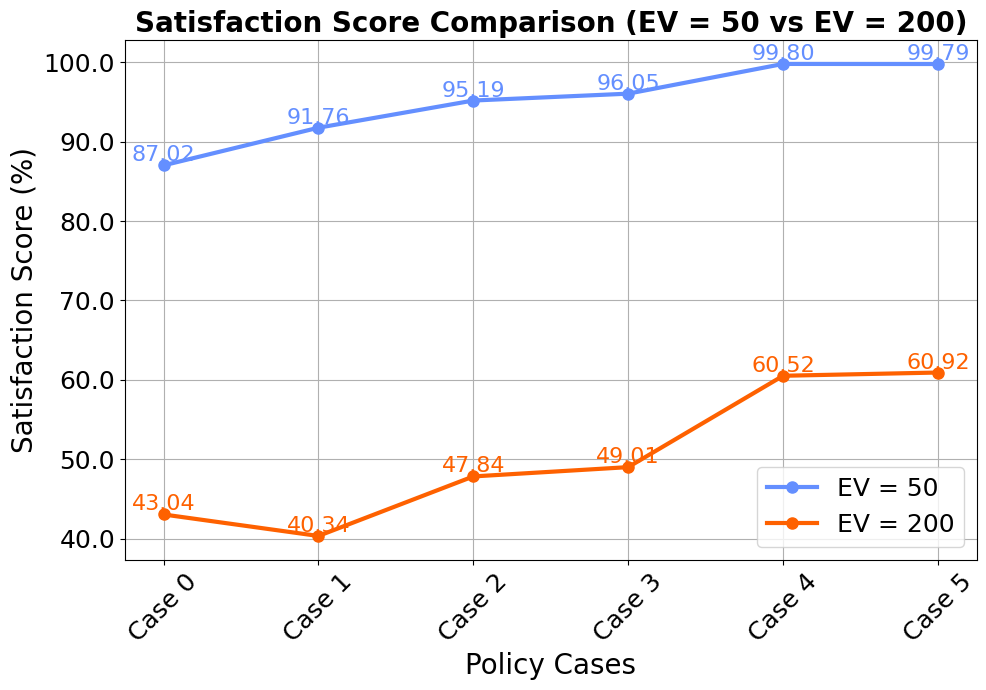

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))

nb_electrical_values = [50, 200]
colors = ["#648FFF", "#FE6100"]

for i, nb_electrical in enumerate(nb_electrical_values):
    subset = df[df["self.nb_electrical"] == nb_electrical]

    x_values = np.arange(6)
    y_values = []

    for j in range(6):
        case_data = subset[subset["case"] == j]
        
        if len(case_data) > 0:
            avg_satisfaction = case_data["self.avg_statisfied_day"].mean() * 100
        else:
            avg_satisfaction = np.nan

        y_values.append(avg_satisfaction)

    ax.plot(x_values, y_values, linestyle='-', color=colors[i], marker='o', markersize=8, linewidth=3, label=f"EV = {nb_electrical}")

    for j, y in enumerate(y_values):
        if not np.isnan(y):
            ax.text(x_values[j], y, f"{y:.2f}", ha='center', va='bottom', fontsize=16, color=colors[i])

ax.set_title("Satisfaction Score Comparison (EV = 50 vs EV = 200)", fontsize=20, fontweight="bold")
ax.set_xlabel("Policy Cases", fontsize=20)
ax.set_ylabel("Satisfaction Score (%)", fontsize=20)
ax.set_xticks(np.arange(6))
ax.set_xticklabels(["Case 0", "Case 1", "Case 2", "Case 3", "Case 4", "Case 5"], fontsize=18, rotation=45)
ax.set_yticklabels(ax.get_yticks(), fontsize=18)
ax.legend(fontsize=18)
ax.grid(True)

plt.tight_layout()
plt.show()


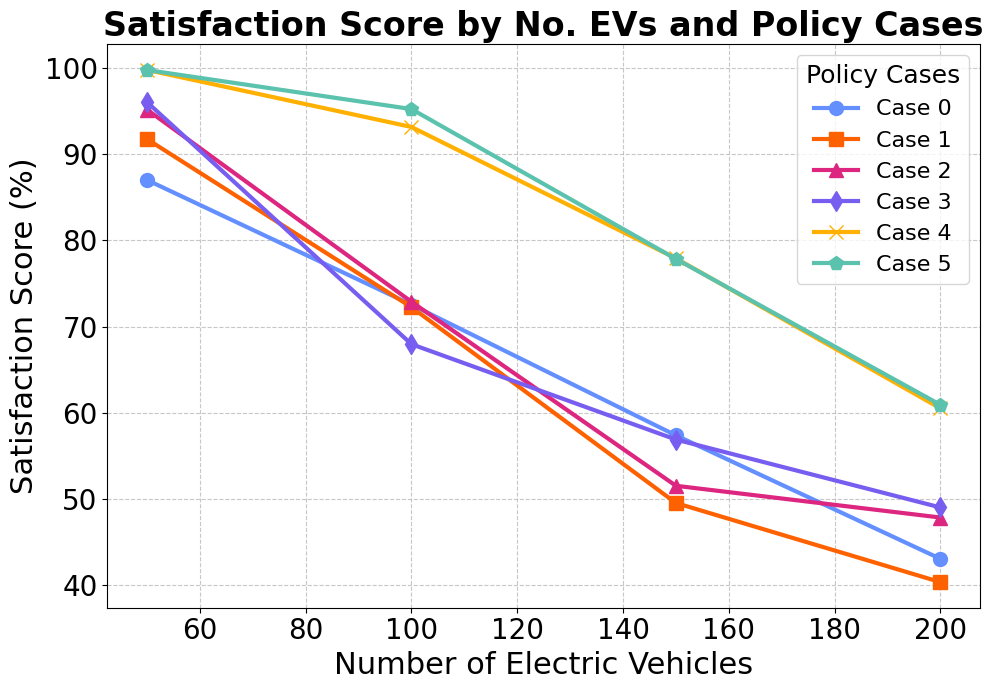

In [18]:
plt.figure(figsize=(10, 7))
nb_electrical_values = [50, 100, 150, 200]
markers = ['o', 's', '^', 'd', 'x', 'p']
colors = ['#648FFF', '#FE6100', '#DC267F', '#785EF0', '#FFB000', '#5AC2AD']

for case in range(6):
    y_values = []

    for nb_electrical in nb_electrical_values:
        case_data = df[(df["self.nb_electrical"] == nb_electrical) & (df["case"] == case)]

        if len(case_data) > 0:
            avg_satisfaction = case_data["self.avg_statisfied_day"].mean() * 100
        else:
            avg_satisfaction = np.nan

        y_values.append(avg_satisfaction)

    plt.plot(nb_electrical_values, y_values, marker=markers[case], markersize=10, color=colors[case],
             linewidth=3, label=f"Case {case}")

plt.title("Satisfaction Score by No. EVs and Policy Cases", 
          fontsize=24, fontweight="bold")
plt.xlabel("Number of Electric Vehicles", fontsize=22)
plt.ylabel("Satisfaction Score (%)", fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Policy Cases", fontsize=16, title_fontsize=18, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# Analysis of Charging Infrastructure Configuration

In [19]:
data_EV50 = pd.read_csv('./viz_data/renew_batch_EV50.csv')
data_EV100 = pd.read_csv('./viz_data/renew_batch_EV100.csv')
data_EV150 = pd.read_csv('./viz_data/renew_batch_EV150.csv')
data_EV200 = pd.read_csv('./viz_data/renew_batch_EV200.csv')

In [20]:
def plot_dual_heatmap(data1, data2, x_col, y_col, z_col, title1, title2, xlabel, ylabel, cmap='viridis', figsize=(14, 6)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    datasets = [data1, data2]
    titles = [title1, title2]
    
    vmin = min(data1[z_col].min(), data2[z_col].min())
    vmax = max(data1[z_col].max(), data2[z_col].max())

    im_list = []

    for idx, (data, ax) in enumerate(zip(datasets, axes)):
        data = data.groupby([x_col, y_col]).mean().reset_index()
        pivot_table = data.pivot(index=y_col, columns=x_col, values=z_col)

        x_labels = pivot_table.columns
        y_labels = pivot_table.index
        values = pivot_table.values

        im = ax.imshow(values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
        im_list.append(im)

        def get_text_color(background_color):
            r, g, b, _ = background_color
            luminance = (0.299 * r + 0.587 * g + 0.114 * b)
            return 'black' if luminance > 0.5 else 'white'

        for i in range(len(y_labels)):
            for j in range(len(x_labels)):
                background_color = im.get_cmap()(im.norm(values[i, j]))
                text_color = get_text_color(background_color)
                ax.text(j, i, f'{values[i, j]:.2f}', ha='center', va='center', color=text_color, fontsize=16)

        ax.set_xticks(np.arange(len(x_labels)))
        ax.set_yticks(np.arange(len(y_labels)))
        ax.set_xticklabels(x_labels, fontsize=16)
        ax.set_yticklabels(y_labels, fontsize=16)

        ax.set_xlabel(xlabel, fontsize=16)
        ax.set_ylabel(ylabel, fontsize=16)
        ax.set_title(titles[idx], fontsize=18, fontweight="bold")

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im_list[0], cax=cbar_ax)
    cbar.set_label('Satisfaction Rate', fontsize=16)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

/var/folders/x2/1k_rr05n63n6yyy4gcwt7lg80000gn/T/ipykernel_7725/4119539856.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


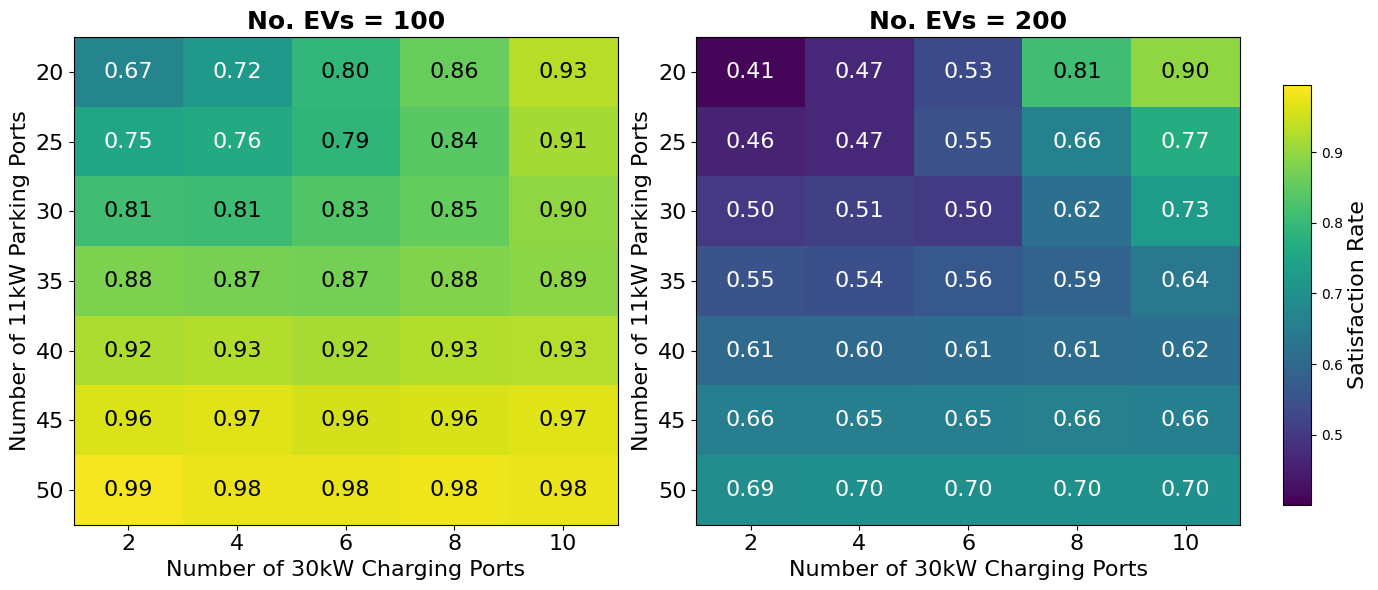

In [21]:
plot_dual_heatmap(
    data1=data_EV100,
    data2=data_EV200,
    x_col='self.nb_activeCS_Cparking_fast',
    y_col='self.nb_activeCS_Cparking',
    z_col='self.avg_statisfied_day',
    title1='No. EVs = 100', 
    title2='No. EVs = 200',
    xlabel='Number of 30kW Charging Ports',
    ylabel='Number of 11kW Parking Ports',
)

In [22]:
def plot_normalized_payback_sufficiency(data, nb_ev):
    grouped_data = data.groupby('self.nb_solar').mean().reset_index()

    fig, ax2 = plt.subplots(figsize=(10, 8))

    ax2.set_xlabel('Number of Solar Panels', fontsize=20)
    ax2.set_ylabel('Normalized Payback Period', color='black', fontsize=20)
    line1, = ax2.plot(grouped_data['self.nb_solar'], grouped_data['self.payback_period_norm'], color = "#648FFF", marker ='x', label='Normalized Payback Period', linewidth=2, markersize=8)
    ax2.tick_params(axis='y', labelcolor='black', labelsize=18)
    ax2.tick_params(axis='x', labelsize=18)

    ax2.set_ylim(0, 1)  

    ax2_right = ax2.twinx()
    ax2_right.set_ylabel('Self-Sufficiency & Self-Consumption', color='black', fontsize=20)
    line2, = ax2_right.plot(grouped_data['self.nb_solar'], grouped_data['self.self_sufficiency'], color = "#FE6100", marker = 'o', label='Self-Sufficiency', linewidth=2, markersize=8)
    line3, = ax2_right.plot(grouped_data['self.nb_solar'], grouped_data['self.self_consumption'], color = "#5AC2AD", marker = 's', label='Self-Consumption', linewidth=2, markersize=8)
    ax2_right.tick_params(axis='y', labelcolor='black', labelsize=18)
    
    ax2_right.set_ylim(0, 1)  

    ax2.set_title(f'Normalized Payback Period vs. Solar Panels (EVs = {nb_ev})', fontsize=19, fontweight='bold')

    lines = [line1, line2, line3]
    labels = [line.get_label() for line in lines]
    ax2.legend(lines, labels, loc='lower right', fontsize=18, facecolor='white', framealpha=1, edgecolor='black')

    fig.tight_layout()
    plt.show()

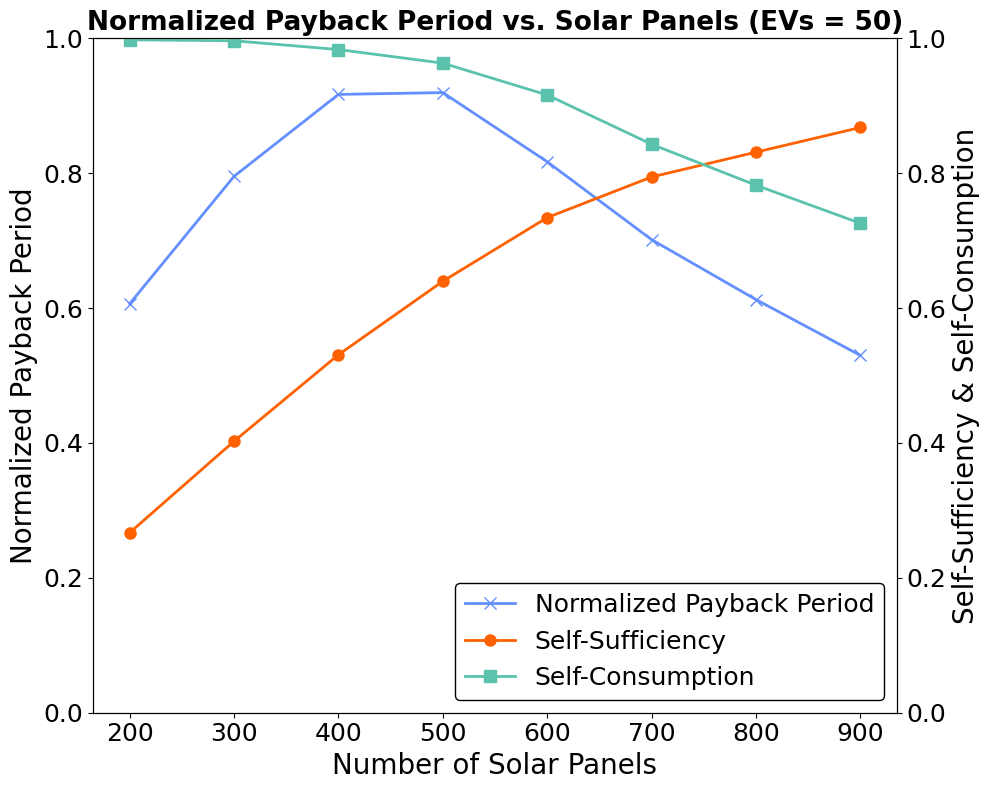

In [23]:
plot_normalized_payback_sufficiency(data_EV50, 50)

# Sobol Analysis

In [24]:
#install Sensitivity Analysis (SA) library
# !pip install SALib

In [25]:
from SALib.sample import saltelli
from SALib.analyze import sobol
from SALib.test_functions import Ishigami

data = pd.read_csv('./viz_data/sobol_raw.csv')
data

,nb_electrical,nb_activeCS_Cparking,nb_activeCS_Cparking_fast,nb_solar,policy_ban_gasoline,policy_idle_fee,policy_relocation,policy_notification,avg_statisfied_day,self_consumption,self_sufficiency,payback_period_norm,metric
0,82,22,6,673,False,True,False,True,0.92,1.00,0.48,0.89,2.19
1,125,22,6,673,False,True,False,True,0.90,1.00,0.44,0.84,2.08
2,82,22,6,673,False,True,False,True,0.92,1.00,0.48,0.89,2.19
3,82,22,2,673,False,True,False,True,0.94,0.98,0.65,0.94,2.40
4,82,22,6,378,False,True,False,True,0.95,1.00,0.28,0.62,1.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,114,30,2,546,True,True,True,True,0.93,1.00,0.29,0.64,1.80
17996,114,30,2,546,False,True,True,True,0.85,1.00,0.29,0.64,1.72
17997,114,30,2,546,False,True,False,True,0.95,1.00,0.34,0.71,1.93
17998,114,30,2,546,False,True,True,False,0.56,1.00,0.39,0.79,1.66


In [26]:
Y1 = data['avg_statisfied_day'].values
Y2 = data['self_consumption'].values 
Y3 = data['self_sufficiency'].values
Y4 = data['payback_period_norm'].values
Y5 = data['metric'].values

bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [27]:
problem = {
  'num_vars': 8,
  'names': ['nb_electrical', 'nb_activeCS_Cparking', 'nb_activeCS_Cparking_fast',  
            'nb_solar', 'policy_ban_gasoline','policy_idle_fee', 'policy_relocation',                   'policy_notification'],
  'bounds': [[50, 200],
             [20, 50],
             [2, 10],
             [200, 900],
             [0, 1],
             [0, 1],
             [0, 1],
             [0, 1]]
}

In [28]:
# Perform analysis
Si1 = sobol.analyze(problem, Y1, print_to_console=True) #indicator 1
Si2 = sobol.analyze(problem, Y2, print_to_console=True) #indicator 2
Si3 = sobol.analyze(problem, Y3, print_to_console=True) #indicator 3
Si4 = sobol.analyze(problem, Y4, print_to_console=True) #indicator 4
Si5 = sobol.analyze(problem, Y5, print_to_console=True) #indicator 5

/Users/linhdo/anaconda3/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/linhdo/anaconda3/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


                            ST  ST_conf
nb_electrical             0.63     0.05
nb_activeCS_Cparking      0.38     0.04
nb_activeCS_Cparking_fast 0.34     0.04
nb_solar                  0.29     0.03
policy_ban_gasoline       0.17     0.03
policy_idle_fee           0.19     0.03
policy_relocation         0.20     0.03
policy_notification       0.37     0.05
                            S1  S1_conf
nb_electrical             0.27     0.07
nb_activeCS_Cparking      0.05     0.05
nb_activeCS_Cparking_fast 0.02     0.05
nb_solar                  0.01     0.04
policy_ban_gasoline       0.02     0.04
policy_idle_fee           0.00     0.03
policy_relocation         0.01     0.04
policy_notification       0.14     0.05
                                                     S2  S2_conf
(nb_electrical, nb_activeCS_Cparking)              0.02     0.09
(nb_electrical, nb_activeCS_Cparking_fast)         0.02     0.08
(nb_electrical, nb_solar)                          0.05     0.10
(nb_electrical, poli

/Users/linhdo/anaconda3/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/linhdo/anaconda3/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


                            ST  ST_conf
nb_electrical             0.29     0.03
nb_activeCS_Cparking      0.09     0.01
nb_activeCS_Cparking_fast 0.04     0.01
nb_solar                  0.58     0.05
policy_ban_gasoline       0.03     0.01
policy_idle_fee           0.09     0.02
policy_relocation         0.10     0.02
policy_notification       0.07     0.01
                            S1  S1_conf
nb_electrical             0.23     0.05
nb_activeCS_Cparking      0.02     0.03
nb_activeCS_Cparking_fast 0.00     0.02
nb_solar                  0.50     0.06
policy_ban_gasoline       0.01     0.01
policy_idle_fee           0.03     0.03
policy_relocation         0.04     0.03
policy_notification       0.02     0.03
                                                     S2  S2_conf
(nb_electrical, nb_activeCS_Cparking)             -0.02     0.07
(nb_electrical, nb_activeCS_Cparking_fast)        -0.03     0.07
(nb_electrical, nb_solar)                          0.00     0.07
(nb_electrical, poli

/Users/linhdo/anaconda3/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


In [29]:
import matplotlib.pyplot as plt
S1_indices = Si1['S1']
ST_indices = Si1['ST']

S1_conf = Si1['S1_conf']
ST_conf = Si1['ST_conf']

S1_error = [conf / 2 for conf in S1_conf]
ST_error = [conf / 2 for conf in ST_conf]

variables = ['No. EVs', 'No. CPs 11kW', 'No. CPs 30kW', 'No. Solar Panels', 'P. Ban Gas Car','P. Idle Fee', 'P. EV Relocation', 'P. Notification']

In [30]:
def sobol_heatmap(data_for_heatmap):
    data_array = np.array(data_for_heatmap)

    fig, ax = plt.subplots(figsize=(10, 6))
    cmap = plt.cm.viridis
    cax = ax.imshow(data_array, cmap=cmap, aspect='auto')

    cbar = fig.colorbar(cax, ax=ax, label='Sensitivity Index')
    cbar.ax.tick_params(labelsize=14)

    ax.set_xticks(np.arange(len(variables)))
    ax.set_yticks(np.arange(len(output_names)))
    ax.set_xticklabels(variables, rotation=25, ha='right', fontsize=14)
    ax.set_yticklabels(output_names, fontsize=14)

    for i in range(len(output_names)):  
        for j in range(len(variables)):  
            value = data_array[i, j]
            bg_color = cmap((value - data_array.min()) / (data_array.max() - data_array.min()))
            brightness = np.mean(bg_color[:3])
            text_color = 'white' if brightness < 0.5 else 'black'
            ax.text(j, i, f"{value:.2f}", ha='center', va='center', color=text_color, fontsize=12)
  
    plt.xlabel('INPUT VARIABLES', fontsize=16)
    plt.ylabel('INDICATORS', fontsize=16)
    plt.title('Total Order Sobol Sensitivity Indices (ST)', fontsize=18, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [31]:
Si_list = [Si1, Si2, Si3, Si4, Si5]
output_names = ['Satisfaction Score', 'Self-Consumption', 'Self-Sufficiency', 'Normalize Payback', 'Objective Function']

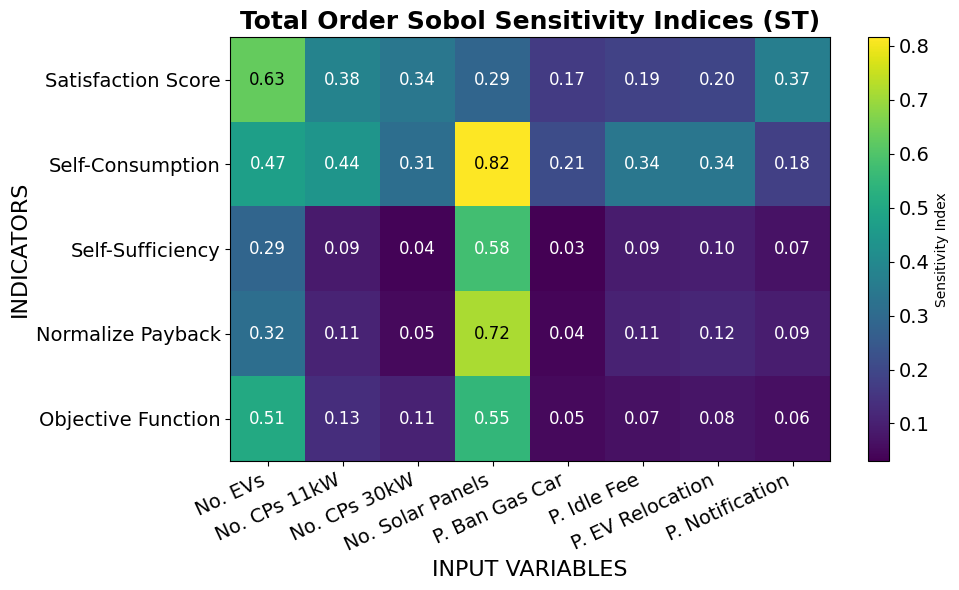

In [32]:
data_for_heatmap = []
for Si in Si_list:
    ST_indices = Si['ST']
    data_for_heatmap.append(ST_indices)
    
sobol_heatmap(data_for_heatmap)

# Evaluate Embedded Optimization Algorithm

In [33]:
import plotly.graph_objects as go

ev_cases = ["EV50", "EV100", "EV150", "EV200"]
pso_11kW = [35, 50, 25, 22]
pso_30kW = [2, 2, 10, 10]
pso_solar = [500, 827, 690, 548]

manual_11kW = [35, 50, 20, 20]
manual_30kW = [4, 4, 10, 10]
manual_solar = [500, 900, 600, 600]

ev_colors = ['#648FFF', '#FE6100', '#5AC2AD', '#DC267F']
ev_symbols = ['circle', 'square', 'diamond', 'cross']

fig = go.Figure()

for i, ev in enumerate(ev_cases):
    fig.add_trace(go.Scatter3d(
        x=[pso_11kW[i]], y=[pso_30kW[i]], z=[pso_solar[i]],
        mode='markers',
        marker=dict(size=10, color=ev_colors[i], symbol=ev_symbols[i]),
        name=f"PSO {ev}"
    ))

for i, ev in enumerate(ev_cases):
    fig.add_trace(go.Scatter3d(
        x=[manual_11kW[i]], y=[manual_30kW[i]], z=[manual_solar[i]],
        mode='markers',
        marker=dict(size=7, color=ev_colors[i], symbol=ev_symbols[i], opacity=0.6),
        name=f"Full-case {ev}"
    ))

fig.update_layout(
    scene=dict(
        xaxis_title="No.CPs 11kW",
        yaxis_title="No.CPs 30kW",
        zaxis_title="No. Solar Panels",
        xaxis=dict(backgroundcolor="rgb(230, 230, 230)"),
        yaxis=dict(backgroundcolor="rgb(230, 230, 230)"),
        zaxis=dict(backgroundcolor="rgb(230, 230, 230)")
    ),
    margin=dict(l=0, r=0, b=50, t=10),

    legend=dict(
        x=0.75,
        y=0.8,
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="black",
        borderwidth=1
    )
)

fig.show()